In [1]:
import os
import torch
import random
import numpy as np
from PIL import Image
from torch.utils.data import Dataset

import torchvision.transforms as T

class MyRatDataset(Dataset):
    """
    A dataset that reads images and YOLO-format annotations from a folder.
    Expected structure:
        root/
          images/
            img1.jpg
            img2.jpg
            ...
          labels/
            img1.txt
            img2.txt
            ...
    Each label file should contain lines (YOLO format):
        class_id  x_center_norm  y_center_norm  width_norm  height_norm
    In this version, we also create negative samples on the fly.
    With a certain probability, we "remove" the rat(s) by filling the bounding box regions with random noise.
    The resulting image is treated as a negative sample (with no bounding boxes).
    """
    def __init__(self, root, transforms=None, negative_sample_ratio=0.3):
        """
        Args:
            root (str): Path to the subset folder (e.g., 'new_dataset/train').
                        Must contain 'images/' and 'labels/' subfolders.
            transforms (callable, optional): Transformations to apply to the PIL image.
            negative_sample_ratio (float): The probability (0 to 1) of generating a negative sample from a positive image.
        """
        self.root = root
        self.transforms = transforms
        self.negative_sample_ratio = negative_sample_ratio
        
        self.img_dir = os.path.join(root, "images")
        self.lbl_dir = os.path.join(root, "labels")
        
        # Collect image file names
        self.imgs = [f for f in os.listdir(self.img_dir)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        self.imgs.sort()  # for consistent ordering

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        # Load image
        img_name = self.imgs[idx]
        img_path = os.path.join(self.img_dir, img_name)
        img = Image.open(img_path).convert("RGB")
        w, h = img.size

        # Load annotations from the corresponding label file
        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_path = os.path.join(self.lbl_dir, label_name)
        
        boxes = []
        labels = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    # YOLO format: class_id, x_center, y_center, width, height (all normalized)
                    class_id = int(parts[0]) + 1
                    x_center_norm = float(parts[1])
                    y_center_norm = float(parts[2])
                    width_norm    = float(parts[3])
                    height_norm   = float(parts[4])
                    
                    # Convert normalized coords to absolute pixel coordinates
                    x_center = x_center_norm * w
                    y_center = y_center_norm * h
                    box_width = width_norm * w
                    box_height = height_norm * h
                    x_min = x_center - box_width / 2
                    y_min = y_center - box_height / 2
                    x_max = x_center + box_width / 2
                    y_max = y_center + box_height / 2
                    boxes.append([x_min, y_min, x_max, y_max])
                    labels.append(class_id)
        
        # If no annotations, treat image as a negative sample naturally
        if len(boxes) == 0:
            boxes = torch.empty((0, 4), dtype=torch.float32)
            labels = torch.empty((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
        
        # Decide whether to generate a negative sample from this image
        # (only if there are boxes, because otherwise it's already negative)
        if boxes.shape[0] > 0 and random.random() < self.negative_sample_ratio:
            # Generate negative sample by filling each bounding box with random noise
            img = self.generate_negative_sample(img, boxes)
            # Set target to have no boxes or labels
            boxes = torch.empty((0, 4), dtype=torch.float32)
            labels = torch.empty((0,), dtype=torch.int64)
        
        image_id = torch.tensor([idx])
        if boxes.size(0) > 0:
            area = (boxes[:,2] - boxes[:,0]) * (boxes[:,3] - boxes[:,1])
        else:
            area = torch.empty((0,), dtype=torch.float32)
        iscrowd = torch.zeros((labels.shape[0],), dtype=torch.int64)
        
        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": image_id,
            "area": area,
            "iscrowd": iscrowd
        }
        
        if self.transforms:
            img = self.transforms(img)
        
        return img, target

    def generate_negative_sample(self, img, boxes):
        """
        Generate a negative sample by filling the regions of each bounding box in the image with random noise.
        Args:
            img (PIL.Image): The original image.
            boxes (Tensor): Tensor of shape [N, 4] with bounding box coordinates in absolute pixel values.
        Returns:
            PIL.Image: The image with the rat regions replaced with noise.
        """
        # Convert PIL image to NumPy array
        img_np = np.array(img)
        # Iterate through each box and fill the region with random noise
        for box in boxes:
            x_min, y_min, x_max, y_max = box.int().tolist()
            # Clip coordinates to image boundaries
            x_min = max(0, x_min)
            y_min = max(0, y_min)
            x_max = min(img_np.shape[1], x_max)
            y_max = min(img_np.shape[0], y_max)
            if x_max > x_min and y_max > y_min:
                noise = np.random.randint(0, 256, (y_max - y_min, x_max - x_min, 3), dtype=np.uint8)
                img_np[y_min:y_max, x_min:x_max, :] = noise
        # Convert back to PIL image
        return Image.fromarray(img_np)

# Example usage
if __name__ == "__main__":
    import torchvision.transforms as T
    
    # Define transforms: converting image to tensor and normalizing
    transforms = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225])
    ])
    
    # Create dataset instance. Adjust root path as needed.
    dataset_root = "new_dataset\\train"  # Folder with subfolders: images/ and labels/
    dataset = MyRatDataset(root=dataset_root, transforms=transforms, negative_sample_ratio=0.3)
    
    # Optionally, inspect a sample
    img, target = dataset[0]
    print("Sample target:", target)
    
    # Create DataLoader
    from torch.utils.data import DataLoader
    dataloader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=lambda batch: tuple(zip(*batch)))
    
    # Iterate over one batch
    for images, targets in dataloader:
        print(f"Batch has {len(images)} images")
        for t in targets:
            print("Boxes:", t["boxes"], "Labels:", t["labels"])
        break


Sample target: {'boxes': tensor([[ 19.0000, 133.2500, 168.0000, 396.7500]]), 'labels': tensor([1]), 'image_id': tensor([0]), 'area': tensor([39261.5000]), 'iscrowd': tensor([0])}
Batch has 4 images
Boxes: tensor([], size=(0, 4)) Labels: tensor([], dtype=torch.int64)
Boxes: tensor([], size=(0, 4)) Labels: tensor([], dtype=torch.int64)
Boxes: tensor([[283.9997,   3.9998, 545.0000, 276.9998]]) Labels: tensor([1])
Boxes: tensor([[2.5000e-01, 2.7275e+02, 1.5575e+02, 5.2025e+02]]) Labels: tensor([1])


In [2]:
import cv2
import numpy as np

def tensor_to_image(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """
    Convert a normalized tensor (C x H x W) back to a uint8 image (H x W x 3) for display.
    """
    # Clone and move tensor to CPU
    tensor = tensor.clone().detach().cpu().numpy()
    # Unnormalize: tensor * std + mean (broadcasting over H and W)
    tensor = tensor * np.array(std)[:, None, None] + np.array(mean)[:, None, None]
    # Transpose to H x W x C
    tensor = np.transpose(tensor, (1, 2, 0))
    # Clip values and convert to uint8
    tensor = np.clip(tensor * 255, 0, 255).astype(np.uint8)
    # Convert from RGB (PIL) to BGR (OpenCV)
    img_bgr = cv2.cvtColor(tensor, cv2.COLOR_RGB2BGR)
    return img_bgr

# --- Iterate over one batch and show the images with OpenCV ---
for images, targets in dataloader:
    print(f"Batch has {len(images)} images")
    for idx, (img_tensor, t) in enumerate(zip(images, targets)):
        # Convert tensor to displayable image
        img_disp = tensor_to_image(img_tensor)
        # Print boxes and labels from target
        print("Boxes:", t["boxes"], "Labels:", t["labels"])
        # Show image
        cv2.imshow(f"Image {idx}", img_disp)
    cv2.waitKey(0)  # Wait indefinitely until a key is pressed
    cv2.destroyAllWindows()
    break


Batch has 4 images
Boxes: tensor([[  5.0000, 246.5000, 178.0000, 590.5000]]) Labels: tensor([1])
Boxes: tensor([], size=(0, 4)) Labels: tensor([], dtype=torch.int64)
Boxes: tensor([[  0.,  56., 224., 296.]]) Labels: tensor([1])
Boxes: tensor([], size=(0, 4)) Labels: tensor([], dtype=torch.int64)


In [3]:
import torch.nn.functional as F

# Define a placeholder function for ddfl loss.
# Replace the contents of this function with your ddfl loss formula.
def compute_ddfl_loss(pred_boxes, target_boxes):
    # Example: using L1 loss between predicted boxes and target boxes
    # Note: You may need to adjust the aggregation based on your loss design.
    return F.l1_loss(pred_boxes, target_boxes)

In [4]:
import os
import torch
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
from torchsummary import summary
from torch.cuda.amp import autocast, GradScaler
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
from torchvision.models.detection import ssdlite320_mobilenet_v3_large, SSDLite320_MobileNet_V3_Large_Weights

# Assume your custom dataset class MyRatDataset is defined elsewhere.
# It should return images (PIL Images) and targets (a dict with keys "boxes", "labels", etc.)

# Define transforms: converting image to tensor and normalizing.
transforms = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

# Create training and validation datasets and dataloaders.
train_dataset = MyRatDataset(root="new_dataset\\train", transforms=transforms, negative_sample_ratio=0.3)
val_dataset   = MyRatDataset(root="new_dataset\\valid", transforms=transforms, negative_sample_ratio=0.0)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=lambda batch: tuple(zip(*batch))
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=lambda batch: tuple(zip(*batch))
)

# Load the SSDLite model with a pretrained backbone and 2 classes (background and rat)
model = ssdlite320_mobilenet_v3_large(
    weights=None,
    num_classes=2,
    weights_backbone=torchvision.models.MobileNet_V3_Large_Weights.IMAGENET1K_V1
)

# Move model to device
device = torch.device("cuda:0")
model.to(device)

# Define a helper to freeze all BatchNorm layers
def freeze_bn(module):
    if isinstance(module, torch.nn.BatchNorm2d):
        module.eval()
        for param in module.parameters():
            param.requires_grad = False

# Freeze all BN layers in the model.
model.apply(freeze_bn)

# Create optimizer (train only detection head parameters)
optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

# Set up AMP scaler and TensorBoard writer.
scaler = GradScaler()
writer = SummaryWriter(log_dir=r"C:\Machine Learning\Rat Tracking using TensorFlow\SSDLite\runs")

train_losses = []
val_losses = []
num_epochs = 40

# Optionally, print a model summary.
summary(model, input_size=(3, 320, 320))

# -----------------------------
# Training and Validation Loop
# -----------------------------
for epoch in range(num_epochs):
    model.train()  # Set detection head to train mode.
    model.apply(freeze_bn)  # Re-freeze all BN layers.
    
    epoch_train_loss = 0.0
    epoch_train_cls_loss = 0.0
    epoch_train_bbox_loss = 0.0
    
    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        # Filter out samples with empty bounding boxes.
        filtered_images = []
        filtered_targets = []
        for img, tgt in zip(images, targets):
            if tgt["boxes"].numel() > 0:
                filtered_images.append(img)
                filtered_targets.append(tgt)
        
        optimizer.zero_grad()
        with autocast():
            if len(filtered_images) == 0:
                total_loss = torch.tensor(0., device=device, requires_grad=True)
            else:
                loss_dict = model(filtered_images, filtered_targets)
                cls_loss = loss_dict["classification"]
                bbox_loss = loss_dict["bbox_regression"]
                total_loss = cls_loss + bbox_loss
        
        # Only perform backward, optimizer step, and update if loss is nonzero.
        if total_loss.item() != 0:
            scaler.scale(total_loss).backward()
            scaler.step(optimizer)
            scaler.update()
        # Otherwise, skip these steps.
        
        epoch_train_loss += total_loss.item()
        if len(filtered_images) > 0:
            epoch_train_cls_loss += cls_loss.item()
            epoch_train_bbox_loss += bbox_loss.item()
    
    epoch_train_loss /= len(train_loader)
    epoch_train_cls_loss /= len(train_loader)
    epoch_train_bbox_loss /= len(train_loader)
    train_losses.append(epoch_train_loss)
    
    writer.add_scalar("Loss/Train/Total", epoch_train_loss, epoch)
    writer.add_scalar("Loss/Train/Class", epoch_train_cls_loss, epoch)
    writer.add_scalar("Loss/Train/BBox", epoch_train_bbox_loss, epoch)
    print(
        f"Epoch {epoch+1}/{num_epochs}: "
        f"Train Total Loss: {epoch_train_loss:.4f}, "
        f"Train cls Loss: {epoch_train_cls_loss:.4f}, "
        f"Train bbox Loss: {epoch_train_bbox_loss:.4f}"
    )
    
    # ------------------
    # Validation Loop
    # ------------------
    model.train()  # SSDLite returns losses only in train mode.
    model.apply(freeze_bn)
    
    epoch_val_loss = 0.0
    epoch_val_cls_loss = 0.0
    epoch_val_bbox_loss = 0.0
    
    with torch.no_grad():
        for images, targets in val_loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            filtered_images = []
            filtered_targets = []
            for img, tgt in zip(images, targets):
                if tgt["boxes"].numel() > 0:
                    filtered_images.append(img)
                    filtered_targets.append(tgt)
            
            if len(filtered_images) == 0:
                total_loss = torch.tensor(0., device=device)
            else:
                loss_dict = model(filtered_images, filtered_targets)
                cls_loss = loss_dict["classification"]
                bbox_loss = loss_dict["bbox_regression"]
                total_loss = cls_loss + bbox_loss
            
            epoch_val_loss += total_loss.item()
            if len(filtered_images) > 0:
                epoch_val_cls_loss += cls_loss.item()
                epoch_val_bbox_loss += bbox_loss.item()
    
    epoch_val_loss /= len(val_loader)
    epoch_val_cls_loss /= len(val_loader)
    epoch_val_bbox_loss /= len(val_loader)
    val_losses.append(epoch_val_loss)
    
    writer.add_scalar("Loss/Val/Total", epoch_val_loss, epoch)
    writer.add_scalar("Loss/Val/Class", epoch_val_cls_loss, epoch)
    writer.add_scalar("Loss/Val/BBox", epoch_val_bbox_loss, epoch)
    
    print(
        f"Epoch {epoch+1}/{num_epochs}: "
        f"Val Total Loss: {epoch_val_loss:.4f}, "
        f"Val cls Loss: {epoch_val_cls_loss:.4f}, "
        f"Val bbox Loss: {epoch_val_bbox_loss:.4f}"
    )

# Save the trained SSDLite model weights.
save_path = "Model.pth"
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")


C:\Users\mzarrar\AppData\Local\Temp\ipykernel_8356\2781942473.py:70: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Layer (type:depth-idx)                             Param #
├─SSDLiteFeatureExtractorMobileNet: 1-1            --
|    └─Sequential: 2-1                             --
|    |    └─Sequential: 3-1                        (869,096)
|    |    └─Sequential: 3-2                        (2,102,856)
|    └─ModuleList: 2-2                             --
|    |    └─Sequential: 3-3                        (381,184)
|    |    └─Sequential: 3-4                        (100,480)
|    |    └─Sequential: 3-5                        (67,712)
|    |    └─Sequential: 3-6                        (25,664)
├─DefaultBoxGenerator: 1-2                         --
├─SSDLiteHead: 1-3                                 --
|    └─SSDLiteClassificationHead: 2-3              --
|    |    └─ModuleList: 3-7                        (64,104)
|    └─SSDLiteRegressionHead: 2-4                  --
|    |    └─ModuleList: 3-8                        (97,584)
├─GeneralizedRCNNTransform: 1-4                    --
Total params: 3,708,680

Epoch 1/40:   0%|          | 0/84 [00:00<?, ?it/s]C:\Users\mzarrar\AppData\Local\Temp\ipykernel_8356\2781942473.py:104: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/40: Train Total Loss: 5.3876, Train cls Loss: 2.7381, Train bbox Loss: 2.6495
Epoch 1/40: Val Total Loss: 5.0751, Val cls Loss: 2.6112, Val bbox Loss: 2.4638


Epoch 2/40: Train Total Loss: 4.7355, Train cls Loss: 2.5069, Train bbox Loss: 2.2286
Epoch 2/40: Val Total Loss: 4.6335, Val cls Loss: 2.4492, Val bbox Loss: 2.1843


...

Epoch 36/40: Train Total Loss: 1.1045, Train cls Loss: 0.7942, Train bbox Loss: 0.3103
Epoch 36/40: Val Total Loss: 2.3865, Val cls Loss: 1.7175, Val bbox Loss: 0.6690


Epoch 37/40: Train Total Loss: 1.0159, Train cls Loss: 0.7156, Train bbox Loss: 0.3003
Epoch 37/40: Val Total Loss: 2.3091, Val cls Loss: 1.6552, Val bbox Loss: 0.6539


Epoch 38/40: Train Total Loss: 1.0634, Train cls Loss: 0.7676, Train bbox Loss: 0.2959
Epoch 38/40: Val Total Loss: 2.3094, Val cls Loss: 1.6584, Val bbox Loss: 0.6509


Epoch 39/40: Train Total Loss: 0.9562, Train cls Loss: 0.6792, Train bbox Loss: 0.2770
Epoch 39/40: Val Total Loss: 2.3163, Val cls Loss: 1.7236, Val bbox Loss: 0.5926


Epoch 40/40: Train Total Loss: 0.9297, Train cls Loss: 0.6683, Train bbox Loss: 0.2614
Epoch 40/40: Val Total Loss: 2.3995, Val cls Loss: 1.8116, Val bbox Loss: 0.5879
Model saved to Model.pth


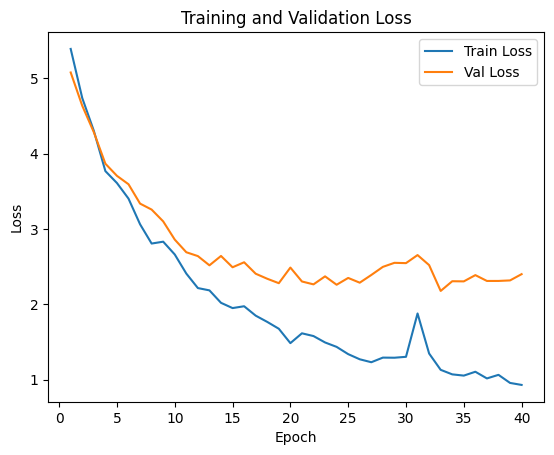

In [8]:
import matplotlib.pyplot as plt

# After your training loop:
epochs = range(1, num_epochs + 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()


In [9]:
def predict(image_path, model, device, threshold=0.7):
        # Load image using PIL
        img = Image.open(image_path).convert("RGB")
        orig_img = np.array(img)  # For visualization
        # Apply transforms
        img_tensor = transforms(img).to(device)
        img_tensor = img_tensor.unsqueeze(0)
        
        model.eval()
        with torch.no_grad():
            outputs = model(img_tensor)
        output = outputs[0]
        boxes = output['boxes'].cpu().numpy()
        scores = output['scores'].cpu().numpy()
        labels = output['labels'].cpu().numpy()
        
        # Filter out detections below threshold
        keep = scores >= threshold
        boxes = boxes[keep]
        scores = scores[keep]
        labels = labels[keep]
        return orig_img, boxes, scores, labels

In [14]:
import cv2
import torch
import torchvision
import torchvision.transforms as T
import numpy as np
from PIL import Image
from torchvision.models.detection import ssdlite320_mobilenet_v3_large, SSDLite320_MobileNet_V3_Large_Weights

# Define transforms (same as during training)
transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

# Set up device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate the SSDLite model with pretrained backbone and 2 classes (background and rat)
model = ssdlite320_mobilenet_v3_large(
    weights=None,
    num_classes=2
)
model.to(device)

# Load custom trained weights (update the path accordingly)
model_path = r"C:\Machine Learning\Rat Tracking using TensorFlow\FastRcNN\Model.pth"
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

def predict(image_input, model, device, threshold=0.7):
    """
    Given an image (file path or numpy array), runs SSDLite inference and returns:
      orig_img: Original image (in BGR, for OpenCV display)
      boxes: numpy array of bounding boxes (N x 4)
      scores: numpy array of detection scores
      labels: numpy array of predicted labels
    """
    # Load image and convert to RGB
    if isinstance(image_input, str):
        pil_img = Image.open(image_input).convert("RGB")
        orig_img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    elif isinstance(image_input, np.ndarray):
        pil_img = Image.fromarray(cv2.cvtColor(image_input, cv2.COLOR_BGR2RGB))
        orig_img = image_input.copy()
    else:
        raise ValueError("Unsupported input type. Provide a file path or a numpy array.")
    
    # Transform image
    img_tensor = transform(pil_img).to(device)
    img_tensor = img_tensor.unsqueeze(0)  # Add batch dimension
    
    with torch.no_grad():
        predictions = model(img_tensor)
    
    # SSDLite returns a list (one dict per image)
    pred = predictions[0]
    boxes = pred["boxes"].cpu().numpy()
    scores = pred["scores"].cpu().numpy()
    labels = pred["labels"].cpu().numpy()
    
    # Filter detections by threshold
    keep = scores >= threshold
    boxes = boxes[keep]
    scores = scores[keep]
    labels = labels[keep]
    
    return orig_img, boxes, scores, labels

# Path to a test image
test_image_path = r"C:\Machine Learning\Rat Tracking using TensorFlow\FastRcNN\new_dataset\test\images\Baseline_frame_000253.jpg"

# Run inference
orig_img, boxes, scores, labels = predict(test_image_path, model, device, threshold=0.7)

# Draw bounding boxes and labels on the image
for box, score, label in zip(boxes, scores, labels):
    x1, y1, x2, y2 = box.astype(int)
    cv2.rectangle(orig_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(orig_img, f"Rat: {score:.2f}", (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# Display the image
cv2.imshow("Predictions", orig_img)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [15]:
import cv2
import torch
import torchvision
import torchvision.transforms as T
import numpy as np
from PIL import Image
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# Define the transform (same as during training)
transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

device = torch.device("cuda")

# Load and modify the detection model
model = ssdlite320_mobilenet_v3_large(
    weights=None,
    num_classes=2
)
model.to(device)

# Load saved weights
model_path = r"C:\Machine Learning\Rat Tracking using TensorFlow\FastRcNN\Model.pth"
model.load_state_dict(torch.load(model_path, map_location=device))

model.eval()

def predict(image_input, model, device, threshold=0.7, nms_threshold=0.3):
    """
    Predict detections on a given image.
    
    Args:
        image_input (str or np.ndarray): If string, treated as file path;
                                           if np.ndarray, treated as an OpenCV BGR image.
        model: The detection model.
        device: Computation device.
        threshold (float): Confidence threshold.
        nms_threshold (float): IoU threshold for non-maximum suppression.
    
    Returns:
        orig_img (np.ndarray): The original image in BGR format.
        boxes (np.ndarray): Array of bounding boxes.
        scores (np.ndarray): Detection scores.
        labels (np.ndarray): Detected labels.
        inference_time_ms (float): Inference time in milliseconds.
    """
    # Check input type and convert accordingly
    if isinstance(image_input, np.ndarray):
        # image_input is a frame (BGR)
        pil_img = Image.fromarray(cv2.cvtColor(image_input, cv2.COLOR_BGR2RGB))
        orig_img = image_input.copy()  # keep a copy in BGR for display
    elif isinstance(image_input, str):
        pil_img = Image.open(image_input).convert("RGB")
        orig_img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    else:
        raise ValueError("Unsupported type for image_input. Must be str or np.ndarray.")
    
    # Apply transforms to create a tensor
    img_tensor = transform(pil_img).to(device)
    img_tensor = img_tensor.unsqueeze(0)  # add batch dimension

    # Measure inference time using OpenCV ticks
    start = cv2.getTickCount()
    with torch.no_grad():
        outputs = model(img_tensor)
    end = cv2.getTickCount()
    inference_time_ms = (end - start) / cv2.getTickFrequency() * 1000.0

    output = outputs[0]
    boxes = output['boxes'].cpu().numpy()
    scores = output['scores'].cpu().numpy()
    labels = output['labels'].cpu().numpy()

    # Filter out detections below confidence threshold
    keep = scores >= threshold
    boxes = boxes[keep]
    scores = scores[keep]
    labels = labels[keep]

    # Apply non-maximum suppression (NMS) to remove overlapping boxes
    if len(boxes) > 0:
        max_idx = np.argmax(scores)
        boxes = boxes[max_idx:max_idx+1]
        scores = scores[max_idx:max_idx+1]
        labels = labels[max_idx:max_idx+1]
        boxes_tensor = torch.tensor(boxes, device=device)
        scores_tensor = torch.tensor(scores, device=device)
        keep_indices = torchvision.ops.nms(boxes_tensor, scores_tensor, nms_threshold)
        keep_indices = keep_indices.cpu().numpy()  # convert indices to numpy array
        boxes = boxes_tensor[keep_indices].cpu().numpy()
        scores = scores_tensor[keep_indices].cpu().numpy()
        labels = labels[keep_indices]

    return orig_img, boxes, scores, labels, inference_time_ms

def main():
    # video_path = r"C:\Machine Learning\Rat Tracking using TensorFlow\Video\BaselineDark.mp4"
    video_path = r"C:\Machine Learning\Rat Tracking using TensorFlow\Video\Baseline.mp4"
    # video_path = r"C:\Machine Learning\Rat Tracking using TensorFlow\Video\TestFile_Video.mp4"
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error opening video file: {video_path}")
        return

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Predict on the current frame (frame is a NumPy array in BGR format)
        orig_img, boxes, scores, labels, inf_time = predict(frame, model, device, threshold=0.2, nms_threshold=0.0)
        print("Labels:", labels)
        print("Inference time (ms):", inf_time)

        # Draw bounding boxes, label text, and centroid red dot on the frame
        for box, score, label in zip(boxes, scores, labels):
            x1, y1, x2, y2 = box.astype(int)
            cv2.rectangle(orig_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(orig_img, f"Rat: {score:.2f}", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
            # Compute and draw the centroid as a red dot
            cx = (x1 + x2) // 2
            cy = (y1 + y2) // 2
            cv2.circle(orig_img, (cx, cy), 3, (0, 0, 255), -1)
        
        # Draw inference time on the frame
        cv2.putText(orig_img, f"Inference: {inf_time:.1f} ms", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 2)
        
        # Display the frame with predictions
        cv2.imshow("Predictions", orig_img)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

if __name__ == "__main__":
    main()


Labels: [1]
Inference time (ms): 26.5751
Labels: [1]
Inference time (ms): 54.3162
Labels: [1]
Inference time (ms): 44.3397
Labels: [1]
Inference time (ms): 21.7954
Labels: [1]
Inference time (ms): 27.0302
Labels: [1]
Inference time (ms): 18.625
Labels: [1]
Inference time (ms): 18.852500000000003
Labels: [1]
Inference time (ms): 20.413
Labels: [1]
Inference time (ms): 18.796400000000002
Labels: [1]
Inference time (ms): 18.8566
Labels: [1]
Inference time (ms): 18.9112
Labels: [1]
Inference time (ms): 19.597
Labels: [1]
Inference time (ms): 19.5939
Labels: [1]
Inference time (ms): 19.252
Labels: [1]
Inference time (ms): 18.8097
Labels: []
Inference time (ms): 18.4855
Labels: []
Inference time (ms): 19.292099999999998
Labels: []
Inference time (ms): 18.740099999999998
Labels: []
Inference time (ms): 18.631
Labels: []
Inference time (ms): 20.694
Labels: []
Inference time (ms): 19.3786
Labels: []
Inference time (ms): 18.109
Labels: []
Inference time (ms): 20.5329
Labels: []
Inference time (m